In [1]:
"""
Bifurcation Dataset Visualiser
===============================
Shows all recordings overlaid per parameter, with:
  • Null recordings         — thin dark lines, low opacity
  • Positive recordings     — thin lines + grey shaded region after bifurcation
  • Highlighted recording   — bold red line + red dashed actual bifurcation line
  • Predicted bifurcation   — blue dashed vertical line (optional)

Usage
─────
    # After training / streaming inference:
    plot_recordings(
        recordings       = all_recordings,
        highlight        = my_recording,
        predicted_t      = 312,           # from streaming detector (optional)
        depth_summary    = "mean",        # how to collapse depth axis
        save_path        = "bifurc.png",  # or None to show interactively
    )
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from typing import Optional

# Import your data structures — adjust the import path to match your project
# from bifurcation_training import Recording, make_synthetic_recordings


# ──────────────────────────────────────────────────────────────────────────────
# Core plot
# ──────────────────────────────────────────────────────────────────────────────

def plot_recordings(
    recordings: list,                       # list[Recording]
    highlight: object,                      # Recording to draw in red
    predicted_t: Optional[int] = None,      # predicted bifurcation timestep
    depth_summary: str = "mean",            # "mean" | "max" | "std" | int (depth index)
    param_names: Optional[list[str]] = None,
    figsize_per_param: tuple = (14, 2.8),
    null_color: str = "#2c2c2c",
    null_alpha: float = 0.12,
    null_lw: float = 0.6,
    pos_color: str = "#5a5a5a",
    pos_alpha: float = 0.18,
    pos_lw: float = 0.6,
    shade_color: str = "#c8c8c8",
    shade_alpha: float = 0.25,
    highlight_color: str = "#d62728",
    highlight_lw: float = 2.0,
    actual_line_color: str = "#d62728",
    predicted_line_color: str = "#1f77b4",
    save_path: Optional[str] = None,
    dpi: int = 150,
):
    """
    Parameters
    ──────────
    recordings      All Recording objects (nulls + positives).
    highlight       The single Recording to draw prominently in red.
    predicted_t     Absolute timestep predicted by the streaming detector.
                    Pass None to omit the predicted line.
    depth_summary   How to collapse the depth dimension before plotting:
                      "mean"  — average across depth (default)
                      "max"   — max across depth
                      "std"   — std across depth (useful for instability signals)
                      int     — use a single depth slice at that index
    param_names     Optional list of axis labels, one per parameter.
    """
    num_params = highlight.data.shape[0]
    T_highlight = highlight.data.shape[2]

    if param_names is None:
        param_names = [f"Parameter {i+1}" for i in range(num_params)]

    fig, axes = plt.subplots(
        num_params, 1,
        figsize=(figsize_per_param[0], figsize_per_param[1] * num_params),
        sharex=True,
    )
    if num_params == 1:
        axes = [axes]

    fig.patch.set_facecolor("#0f0f0f")
    for ax in axes:
        ax.set_facecolor("#161616")
        for spine in ax.spines.values():
            spine.set_edgecolor("#333333")
        ax.tick_params(colors="#aaaaaa", labelsize=8)
        ax.yaxis.label.set_color("#cccccc")
        ax.xaxis.label.set_color("#cccccc")

    def summarise(data, param_idx):
        """Collapse (depth, time) → (time,) for one parameter."""
        d = data[param_idx]                     # (depth, time)
        if isinstance(depth_summary, int):
            return d[depth_summary]
        elif depth_summary == "mean":
            return d.mean(axis=0)
        elif depth_summary == "max":
            return d.max(axis=0)
        elif depth_summary == "std":
            return d.std(axis=0)
        else:
            raise ValueError(f"Unknown depth_summary='{depth_summary}'")

    # ── Pass 1: nulls ─────────────────────────────────────────────────────
    for rec in recordings:
        if rec.is_positive or rec is highlight:
            continue
        T = rec.data.shape[2]
        t = np.arange(T)
        for p_idx, ax in enumerate(axes):
            signal = summarise(rec.data, p_idx)
            ax.plot(t, signal, color=null_color, alpha=null_alpha,
                    lw=null_lw, rasterized=True)

    # ── Pass 2: positives (not highlight) — line + shaded post-bifurc ────
    for rec in recordings:
        if not rec.is_positive or rec is highlight:
            continue
        T = rec.data.shape[2]
        t = np.arange(T)
        bf = rec.bifurcation_t
        for p_idx, ax in enumerate(axes):
            signal = summarise(rec.data, p_idx)
            ax.plot(t, signal, color=pos_color, alpha=pos_alpha,
                    lw=pos_lw, rasterized=True)
            # Grey shading after bifurcation
            ax.axvspan(bf, T - 1, color=shade_color, alpha=shade_alpha,
                       zorder=0, lw=0)

    # ── Pass 3: highlighted recording ─────────────────────────────────────
    T_h = highlight.data.shape[2]
    t_h = np.arange(T_h)

    for p_idx, ax in enumerate(axes):
        signal = summarise(highlight.data, p_idx)

        # Split into pre / post bifurcation for subtle shading
        if highlight.is_positive:
            bf = highlight.bifurcation_t
            # Post-bifurcation shading specific to this recording
            ax.axvspan(bf, T_h - 1,
                       color=highlight_color, alpha=0.07, zorder=1, lw=0)

        # Main highlighted signal
        ax.plot(t_h, signal,
                color=highlight_color, lw=highlight_lw,
                alpha=0.95, zorder=4, rasterized=True)

        # ── Vertical lines ────────────────────────────────────────────────
        if highlight.is_positive:
            ax.axvline(
                highlight.bifurcation_t,
                color=actual_line_color, lw=1.5, ls="--",
                alpha=0.9, zorder=5,
                label="Actual bifurcation" if p_idx == 0 else None,
            )

        if predicted_t is not None:
            ax.axvline(
                predicted_t,
                color=predicted_line_color, lw=1.5, ls="--",
                alpha=0.9, zorder=5,
                label="Predicted bifurcation" if p_idx == 0 else None,
            )

        # ── Y-label ───────────────────────────────────────────────────────
        label = param_names[p_idx]
        if depth_summary != "mean":
            summary_label = (
                f"depth[{depth_summary}]" if isinstance(depth_summary, int)
                else depth_summary
            )
            label += f"\n({summary_label})"
        ax.set_ylabel(label, fontsize=9, color="#cccccc")
        ax.grid(axis="x", color="#2a2a2a", lw=0.5)
        ax.grid(axis="y", color="#1e1e1e", lw=0.4)

    axes[-1].set_xlabel("Timestep", fontsize=10, color="#aaaaaa")

    # ── Title ─────────────────────────────────────────────────────────────
    rec_id = getattr(highlight, "recording_id", "highlighted")
    title_parts = [f"Recording: {rec_id}"]
    if highlight.is_positive:
        title_parts.append(f"actual bifurcation t={highlight.bifurcation_t}")
    if predicted_t is not None:
        err = predicted_t - highlight.bifurcation_t if highlight.is_positive else None
        err_str = f"  (error: {err:+d} steps)" if err is not None else ""
        title_parts.append(f"predicted t={predicted_t}{err_str}")

    fig.suptitle("  |  ".join(title_parts),
                 fontsize=11, color="#eeeeee", y=1.002,
                 fontfamily="monospace")

    # ── Legend ────────────────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], color=null_color,        alpha=0.6, lw=1.2, label="Null recordings"),
        Line2D([0], [0], color=pos_color,          alpha=0.6, lw=1.2, label="Positive recordings"),
        mpatches.Patch(color=shade_color,          alpha=0.5,         label="Post-bifurcation region"),
        Line2D([0], [0], color=highlight_color,    alpha=0.9, lw=2.0, label=f"Highlighted: {rec_id}"),
        Line2D([0], [0], color=actual_line_color,  alpha=0.9, lw=1.5,
               ls="--", label="Actual bifurcation"),
    ]
    if predicted_t is not None:
        legend_elements.append(
            Line2D([0], [0], color=predicted_line_color, alpha=0.9, lw=1.5,
                   ls="--", label="Predicted bifurcation")
        )

    axes[0].legend(
        handles=legend_elements,
        loc="upper left",
        framealpha=0.2,
        facecolor="#1a1a1a",
        edgecolor="#444444",
        fontsize=8,
        labelcolor="#cccccc",
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"  Saved → {save_path}")
    else:
        plt.show()

    return fig, axes


# ──────────────────────────────────────────────────────────────────────────────
# Convenience wrapper: pick the highlight recording automatically
# ──────────────────────────────────────────────────────────────────────────────

def plot_from_detector_result(
    recordings: list,
    streaming_alerts: list,             # list[BifurcationAlert] from the detector
    highlight_recording_id: str,
    window_len: int = 128,
    **plot_kwargs,
):
    """
    Convenience wrapper when you have streaming alerts and want to plot
    a specific recording with the detector's best prediction overlaid.

    The predicted_t is taken from the alert with the highest confidence.
    """
    rec_map = {r.recording_id: r for r in recordings}
    highlight = rec_map[highlight_recording_id]

    predicted_t = None
    if streaming_alerts:
        best = max(streaming_alerts, key=lambda a: a.p_bifurcation)
        predicted_t = best.predicted_bifurc_t

    return plot_recordings(
        recordings=recordings,
        highlight=highlight,
        predicted_t=predicted_t,
        **plot_kwargs,
    )


# ──────────────────────────────────────────────────────────────────────────────
# Demo
# ──────────────────────────────────────────────────────────────────────────────

# if __name__ == "__main__":
    # # ── Inline minimal Recording class so this file runs standalone ───────
    # from dataclasses import dataclass

    # @dataclass
    # class Recording:
    #     data: np.ndarray
    #     bifurcation_t: int | None
    #     recording_id: str

    #     @property
    #     def is_positive(self):
    #         return self.bifurcation_t is not None

    # # ── Generate synthetic data ───────────────────────────────────────────
    # rng = np.random.default_rng(42)
    # NUM_PARAMS, DEPTH, TIME = 4, 32, 512

    # def ou_process(T, D, P, rng, theta=0.1, sigma=0.3):
    #     x = np.zeros((P, D, T))
    #     for t in range(1, T):
    #         x[:, :, t] = (
    #             x[:, :, t-1]
    #             - theta * x[:, :, t-1]
    #             + sigma * rng.standard_normal((P, D))
    #         )
    #     return x

    # recordings = []

    # # Nulls
    # for i in range(30):
    #     data = ou_process(TIME, DEPTH, NUM_PARAMS, rng)
    #     recordings.append(Recording(data, None, f"null_{i:03d}"))

    # # Positives
    # for i in range(15):
    #     bf_t = int(rng.uniform(0.25 * TIME, 0.75 * TIME))
    #     data = ou_process(TIME, DEPTH, NUM_PARAMS, rng)
    #     for t in range(bf_t, TIME):
    #         scale = 1.0 + 3.0 * (t - bf_t) / (TIME - bf_t)
    #         data[:, :, t] *= scale
    #         data[:, :, t] += 0.4 * rng.standard_normal((NUM_PARAMS, DEPTH))
    #     recordings.append(Recording(data, bf_t, f"pos_{i:03d}"))

    # Pick highlight and simulate a predicted_t with a small error
    # highlight = next(r for r in recordings if r.is_positive)
    # simulated_predicted_t = highlight.bifurcation_t + int(rng.integers(-18, 18))

    # print(f"Highlight: {highlight.recording_id}")
    # print(f"  Actual bifurcation    : t={highlight.bifurcation_t}")
    # print(f"  Simulated prediction  : t={simulated_predicted_t}")
    # rec = pos_recs[0]
    # print(f"Highlight: {rec.recording_id}")
    # print(f"  Actual bifurcation    : t={rec.bifurcation_t}")
    # print(f"  Simulated prediction  : t={alert.predicted_bifurc_t}")

    # plot_recordings(
    #     recordings=test_recs,#recordings,
    #     highlight=rec,#highlight,
    #     predicted_t=alert.predicted_bifurc_t,
    #     depth_summary="mean",
    #     param_names=["Temperature", "Pressure", "Salinity", "Oxygen"],
    #     save_path="bifurcation_plot.png",
    # )

Device: cuda

── Generating synthetic recordings ──
  Train recordings: 70  Val: 15  Test: 15

── Building window datasets ──
  Dataset: 8470 windows  (792 positive = 9.4%)
  Dataset: 1815 windows  (80 positive = 4.4%)
  Dataset: 1815 windows  (56 positive = 3.1%)

── Training ──
  Trainable parameters: 5,058,626

Epoch 001/50  | train loss=0.2013  det=0.0428  reg=0.0793  acc=0.892  t_mae=0.8343  || val loss=0.0691  det=0.0257  acc=0.956  t_mae=0.5152
Epoch 002/50  | train loss=0.1933  det=0.0415  reg=0.0759  acc=0.904  t_mae=0.8140  || val loss=0.0741  det=0.0307  acc=0.956  t_mae=0.5155
Epoch 003/50  | train loss=0.1948  det=0.0412  reg=0.0768  acc=0.905  t_mae=0.8143  || val loss=0.0611  det=0.0252  acc=0.967  t_mae=0.4113
Epoch 004/50  | train loss=0.1874  det=0.0403  reg=0.0735  acc=0.903  t_mae=0.7836  || val loss=0.0416  det=0.0190  acc=0.979  t_mae=0.2530
Epoch 005/50  | train loss=0.1786  det=0.0398  reg=0.0694  acc=0.892  t_mae=0.7519  || val loss=0.0379  det=0.0221  acc=0.95

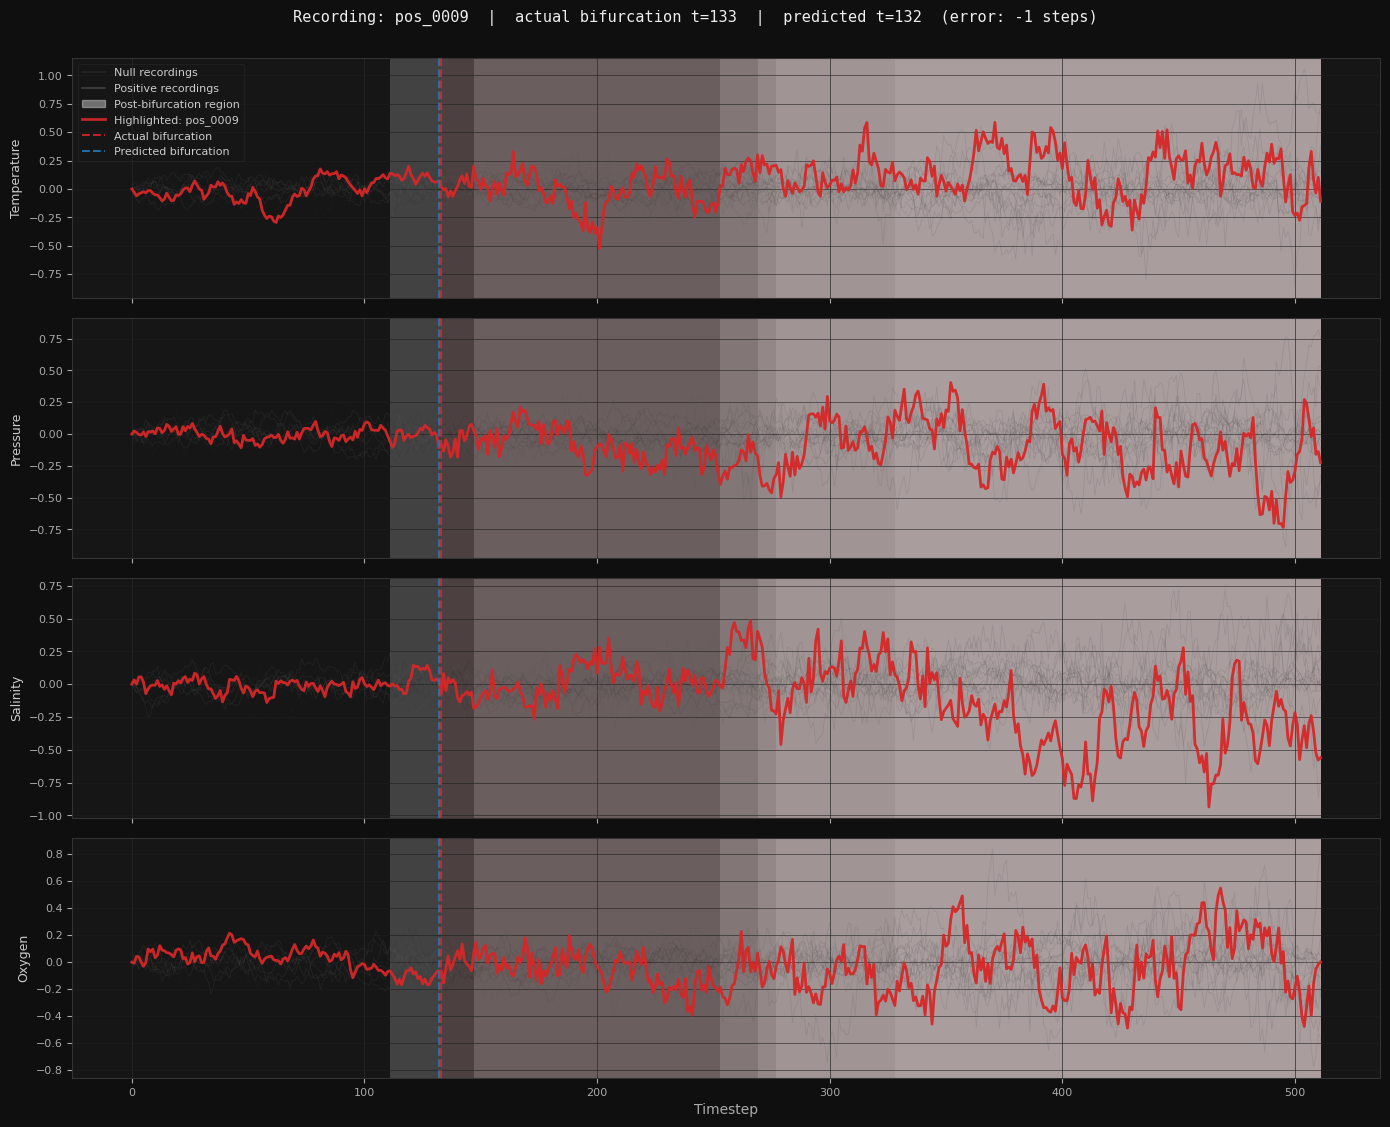

In [12]:
"""
Bifurcation Detection — Regression Training Pipeline & Streaming Deployment
============================================================================

Model outputs TWO heads per window:
  • p_bifurc  : P(a bifurcation exists in this window)          — binary [0,1]
  • t_bifurc  : normalised timestep of bifurcation ∈ [0,1]      — regression
                (only meaningful / penalised when p_bifurc > 0)

Why two heads?
  Null windows have no meaningful regression target.  Penalising the timestep
  head on null samples would force the network to predict an arbitrary number,
  corrupting the gradient signal.  Instead the regression loss is gated by
  whether the window actually contains a bifurcation.

Normalised timestep convention
  t_norm = (bifurcation_absolute_timestep − window_start) / window_length
  So t_norm=0.0 → bifurcation at the very start of the window
     t_norm=1.0 → bifurcation at the very end

Streaming deployment
  A rolling window strides across incoming data. Each stride produces:
    • updated p_bifurc estimate
    • predicted absolute timestep of the bifurcation
  An alert fires when p_bifurc passes a configurable threshold, with
  hysteresis to avoid duplicate alerts.
"""

import math
import time
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


# ──────────────────────────────────────────────────────────────────────────────
# Data structures
# ──────────────────────────────────────────────────────────────────────────────

@dataclass
class Recording:
    """
    A single (possibly multi-parameter) depth×time recording.

    data            : np.ndarray  shape (num_params, depth, time)
    bifurcation_t   : int | None  — absolute timestep of bifurcation,
                                    or None if this is a null recording
    recording_id    : str         — unique identifier (for record-level splits)
    """
    data: np.ndarray
    bifurcation_t: Optional[int]
    recording_id: str

    @property
    def is_positive(self) -> bool:
        return self.bifurcation_t is not None

    @property
    def num_params(self) -> int:
        return self.data.shape[0]

    @property
    def depth(self) -> int:
        return self.data.shape[1]

    @property
    def time_len(self) -> int:
        return self.data.shape[2]


# ──────────────────────────────────────────────────────────────────────────────
# Dataset  — recording-level split, correct window labelling
# ──────────────────────────────────────────────────────────────────────────────

class BifurcationWindowDataset(Dataset):
    """
    Slices recordings into fixed-length windows with stride.

    Label assignment (critical to get right)
    ─────────────────────────────────────────
    For each window [t_start, t_start + window_len):
      • NULL recording              → p=0, t_norm=NaN  (regression ignored)
      • Positive, bifurc before window start → p=0, t_norm=NaN  (precursor only)
      • Positive, bifurc inside window       → p=1, t_norm=(bifurc-t_start)/window_len
      • Positive, bifurc after window end    → p=0, t_norm=NaN  (no bifurc yet)

    The third case is the only positive training example.  This ensures the
    model learns to detect the bifurcation event itself (and its precursors
    within the window), not just the dynamics of a positive recording.

    Precursor window option
    ───────────────────────
    If precursor_steps > 0, windows that *end* exactly precursor_steps before
    the bifurcation are also labelled positive, with t_norm slightly > 1.0.
    This teaches the model to anticipate approaching bifurcations.
    Leave at 0 to disable.
    """

    def __init__(
        self,
        recordings: list[Recording],
        window_len: int = 128,
        stride: int = 16,
        precursor_steps: int = 0,
        normalise: bool = True,
    ):
        self.window_len = window_len
        self.stride = stride
        self.normalise = normalise

        # Each sample: (recording_idx, t_start, p_label, t_norm_label)
        self.samples: list[tuple[int, int, float, float]] = []
        self.recordings = recordings

        for rec_idx, rec in enumerate(recordings):
            T = rec.time_len
            for t_start in range(0, T - window_len + 1, stride):
                t_end = t_start + window_len

                if not rec.is_positive:
                    self.samples.append((rec_idx, t_start, 0.0, float("nan")))
                    continue

                bf = rec.bifurcation_t

                # Bifurcation strictly inside this window
                if t_start <= bf < t_end:
                    t_norm = (bf - t_start) / window_len
                    self.samples.append((rec_idx, t_start, 1.0, t_norm))

                # Precursor window: bifurcation is just ahead
                elif precursor_steps > 0 and (t_end <= bf < t_end + precursor_steps):
                    t_norm = (bf - t_start) / window_len   # > 1.0, intentionally
                    self.samples.append((rec_idx, t_start, 1.0, t_norm))

                else:
                    self.samples.append((rec_idx, t_start, 0.0, float("nan")))

        pos = sum(1 for *_, p, _ in self.samples if p > 0)
        print(
            f"  Dataset: {len(self.samples)} windows  "
            f"({pos} positive = {100*pos/len(self.samples):.1f}%)"
        )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        rec_idx, t_start, p_label, t_norm = self.samples[idx]
        rec = self.recordings[rec_idx]

        # Slice window: (P, D, T_window)
        x = rec.data[:, :, t_start : t_start + self.window_len].copy()
        x = torch.from_numpy(x).float()

        if self.normalise:
            # Per-window z-score per parameter
            mean = x.mean(dim=(1, 2), keepdim=True)
            std  = x.std(dim=(1, 2), keepdim=True).clamp(min=1e-6)
            x = (x - mean) / std

        p_tensor = torch.tensor([p_label], dtype=torch.float32)
        t_tensor = torch.tensor([t_norm],  dtype=torch.float32)

        return x, p_tensor, t_tensor


def recording_level_split(
    recordings: list[Recording],
    val_frac: float = 0.15,
    test_frac: float = 0.15,
    seed: int = 42,
) -> tuple[list[Recording], list[Recording], list[Recording]]:
    """
    Split recordings (NOT windows) into train / val / test.

    Splitting by window would allow windows from the same recording to
    appear in both train and val — the model would memorise the recording.
    """
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(recordings)).tolist()

    n_val  = max(1, int(len(recordings) * val_frac))
    n_test = max(1, int(len(recordings) * test_frac))

    test_idx  = indices[:n_test]
    val_idx   = indices[n_test : n_test + n_val]
    train_idx = indices[n_test + n_val :]

    return (
        [recordings[i] for i in train_idx],
        [recordings[i] for i in val_idx],
        [recordings[i] for i in test_idx],
    )


# ──────────────────────────────────────────────────────────────────────────────
# Model — two-head CNN-LSTM
# ──────────────────────────────────────────────────────────────────────────────

class DepthTimeEncoder(nn.Module):
    def __init__(self, num_params: int, out_channels: int, dropout: float = 0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(num_params, 64,  kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout2d(dropout),

            nn.Conv2d(64, 128, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(dropout),

            nn.Conv2d(128, out_channels, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Dropout2d(dropout),
        )
        self.depth_pool = nn.AdaptiveAvgPool2d((1, None))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.encoder(x)          # (B, C, D', T')
        feat = self.depth_pool(feat)    # (B, C, 1, T')
        return feat.squeeze(2)          # (B, C, T')


class BifurcationRegressor(nn.Module):
    """
    Two-head model:
      • detection_head  → P(bifurcation in window)   scalar in [0, 1]
      • timing_head     → normalised timestep t_norm  scalar in [0, 1+]
                          (sigmoid output, so naturally bounded near [0,1])

    The timing head output is only trusted when detection_head > threshold.
    """

    def __init__(
        self,
        num_params: int  = 4,
        cnn_channels: int = 256,
        lstm_hidden: int  = 256,
        lstm_layers: int  = 3,
        attn_heads: int   = 8,
        dropout: float    = 0.3,
    ):
        super().__init__()

        self.encoder = DepthTimeEncoder(num_params, cnn_channels, dropout)

        self.attn_norm = nn.LayerNorm(cnn_channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=cnn_channels, num_heads=attn_heads,
            dropout=dropout, batch_first=True,
        )

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )

        feat_dim = lstm_hidden * 2

        # Shared trunk
        self.shared = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Head 1: binary detection
        self.detection_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

        # Head 2: timing regression
        # Sigmoid keeps output in [0, 1]; for precursor windows slightly > 1
        # the model will be close enough for deployment purposes.
        self.timing_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor):
        # x: (B, P, D, T)
        feat = self.encoder(x)              # (B, C, T')
        feat = feat.permute(0, 2, 1)        # (B, T', C)

        residual = feat
        feat = self.attn_norm(feat)
        feat, _ = self.attn(feat, feat, feat)
        feat = feat + residual

        out, _ = self.lstm(feat)            # (B, T', H*2)
        out = out[:, -1, :]                 # (B, H*2)

        shared = self.shared(out)           # (B, 256)
        p_bifurc = self.detection_head(shared)   # (B, 1)
        t_norm   = self.timing_head(shared)       # (B, 1)

        return p_bifurc, t_norm


# ──────────────────────────────────────────────────────────────────────────────
# Loss — gated regression
# ──────────────────────────────────────────────────────────────────────────────

class GatedBifurcationLoss(nn.Module):
    """
    Combined loss:

      L = λ_det · FocalLoss(p_pred, p_true)
        + λ_reg · mask · HuberLoss(t_pred, t_true)

    where mask = 1 only for windows that actually contain a bifurcation.

    Gating the regression loss is critical:
      • Null windows have no ground-truth timestep — punishing the network
        for any output on those samples corrupts training.
      • It also means the model is free to output any timing on null windows
        without penalty; only the detection head matters there.
    """

    def __init__(
        self,
        lambda_det: float = 1.0,
        lambda_reg: float = 2.0,
        focal_alpha: float = 0.75,
        focal_gamma: float = 2.0,
        huber_delta: float = 0.1,
    ):
        super().__init__()
        self.lambda_det = lambda_det
        self.lambda_reg = lambda_reg
        self.alpha = focal_alpha
        self.gamma = focal_gamma
        self.huber = nn.HuberLoss(reduction="none", delta=huber_delta)

    def forward(
        self,
        p_pred: torch.Tensor,   # (B, 1)
        t_pred: torch.Tensor,   # (B, 1)
        p_true: torch.Tensor,   # (B, 1)
        t_true: torch.Tensor,   # (B, 1)  — NaN for null windows
    ) -> tuple[torch.Tensor, dict]:

        # ── Focal detection loss ──────────────────────────────────────────
        bce = F.binary_cross_entropy(p_pred, p_true, reduction="none")
        p_t = p_pred * p_true + (1 - p_pred) * (1 - p_true)
        focal_w = (1 - p_t) ** self.gamma
        alpha_t = self.alpha * p_true + (1 - self.alpha) * (1 - p_true)
        det_loss = (alpha_t * focal_w * bce).mean()

        # ── Gated Huber regression loss ───────────────────────────────────
        mask = (~torch.isnan(t_true)) & (p_true > 0)   # (B, 1) bool
        reg_loss = torch.tensor(0.0, device=p_pred.device)

        if mask.any():
            t_pred_masked = t_pred[mask]
            t_true_masked = t_true[mask]
            reg_loss = self.huber(t_pred_masked, t_true_masked).mean()

        total = self.lambda_det * det_loss + self.lambda_reg * reg_loss

        return total, {
            "det_loss": det_loss.item(),
            "reg_loss": reg_loss.item() if mask.any() else 0.0,
        }


# ──────────────────────────────────────────────────────────────────────────────
# Training utilities
# ──────────────────────────────────────────────────────────────────────────────

def collate_nan_safe(batch):
    """Custom collate that stacks tensors containing NaN safely."""
    xs, ps, ts = zip(*batch)
    return torch.stack(xs), torch.stack(ps), torch.stack(ts)


def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=1.0):
    model.train()
    totals = {"loss": 0, "det_loss": 0, "reg_loss": 0, "det_acc": 0, "timing_mae": 0}
    n_timing, n_total = 0, 0

    for x, p_true, t_true in loader:
        x, p_true, t_true = x.to(device), p_true.to(device), t_true.to(device)
        optimizer.zero_grad()

        p_pred, t_pred = model(x)
        loss, breakdown = criterion(p_pred, t_pred, p_true, t_true)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        B = x.size(0)
        totals["loss"]     += loss.item() * B
        totals["det_loss"] += breakdown["det_loss"] * B
        totals["reg_loss"] += breakdown["reg_loss"] * B
        totals["det_acc"]  += ((p_pred > 0.5).float() == p_true).float().sum().item()

        # Timing MAE on positive windows only
        mask = (~torch.isnan(t_true)) & (p_true > 0)
        if mask.any():
            mae = (t_pred[mask] - t_true[mask]).abs().mean().item()
            totals["timing_mae"] += mae * mask.sum().item()
            n_timing += mask.sum().item()

        n_total += B

    return {k: v / (n_timing if "timing" in k and n_timing > 0 else n_total)
            for k, v in totals.items()}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    totals = {"loss": 0, "det_loss": 0, "reg_loss": 0, "det_acc": 0, "timing_mae": 0}
    n_timing, n_total = 0, 0

    for x, p_true, t_true in loader:
        x, p_true, t_true = x.to(device), p_true.to(device), t_true.to(device)
        p_pred, t_pred = model(x)
        loss, breakdown = criterion(p_pred, t_pred, p_true, t_true)

        B = x.size(0)
        totals["loss"]     += loss.item() * B
        totals["det_loss"] += breakdown["det_loss"] * B
        totals["reg_loss"] += breakdown["reg_loss"] * B
        totals["det_acc"]  += ((p_pred > 0.5).float() == p_true).float().sum().item()

        mask = (~torch.isnan(t_true)) & (p_true > 0)
        if mask.any():
            mae = (t_pred[mask] - t_true[mask]).abs().mean().item()
            totals["timing_mae"] += mae * mask.sum().item()
            n_timing += mask.sum().item()

        n_total += B

    return {k: v / (n_timing if "timing" in k and n_timing > 0 else n_total)
            for k, v in totals.items()}


def train(
    model,
    train_ds,
    val_ds,
    device,
    epochs: int = 30,
    batch_size: int = 32,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 7,
    save_path: Optional[str] = "best_model.pt",
):
    """
    Full training loop with:
      • AdamW + cosine LR schedule
      • Early stopping on val loss
      • Best checkpoint saving
    """
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        collate_fn=collate_nan_safe, num_workers=0,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        collate_fn=collate_nan_safe, num_workers=0,
    )

    criterion = GatedBifurcationLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        print(
            f"Epoch {epoch:03d}/{epochs}  "
            f"| train loss={tr['loss']:.4f}  det={tr['det_loss']:.4f}  reg={tr['reg_loss']:.4f}  "
            f"acc={tr['det_acc']:.3f}  t_mae={tr['timing_mae']:.4f}"
            f"  || val loss={va['loss']:.4f}  det={va['det_loss']:.4f}  "
            f"acc={va['det_acc']:.3f}  t_mae={va['timing_mae']:.4f}"
        )

        if va["loss"] < best_val_loss:
            best_val_loss = va["loss"]
            patience_counter = 0
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f"  ✓ Saved checkpoint (val_loss={best_val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop at epoch {epoch}")
                break

    if save_path and Path(save_path).exists():
        model.load_state_dict(torch.load(save_path, map_location=device))
        print("  ✓ Loaded best checkpoint")

    return model


# ──────────────────────────────────────────────────────────────────────────────
# Streaming inference — rolling window alerting
# ──────────────────────────────────────────────────────────────────────────────

@dataclass
class BifurcationAlert:
    """Fired when the model believes a bifurcation is imminent or occurring."""
    absolute_timestep: int          # current position in the stream
    p_bifurcation: float            # model confidence [0,1]
    predicted_bifurc_t: int         # predicted absolute timestep of bifurcation
    steps_until_bifurc: int         # predicted_bifurc_t - absolute_timestep
                                    #   negative = already occurred in this window


class StreamingBifurcationDetector:
    """
    Wraps a trained BifurcationRegressor for real-time rolling-window inference.

    Usage
    ─────
        detector = StreamingBifurcationDetector(model, window_len=128, stride=16)
        for new_slice in data_stream:           # new_slice: (P, D, stride)
            alerts = detector.push(new_slice)
            for alert in alerts:
                handle_alert(alert)

    Hysteresis
    ──────────
    An alert fires when p_bifurc crosses `threshold` from below.
    The detector then enters a cooldown of `cooldown_steps` timesteps
    before it can fire again — preventing a cascade of duplicate alerts
    from overlapping windows that all detect the same bifurcation.

    Exponential smoothing
    ─────────────────────
    Raw per-window probabilities are noisy.  We apply an EMA (alpha controls
    responsiveness vs. smoothness) before threshold comparison.
    """

    def __init__(
        self,
        model: BifurcationRegressor,
        window_len: int = 128,
        stride: int = 16,
        threshold: float = 0.6,
        cooldown_steps: int = 64,
        ema_alpha: float = 0.4,
        device: Optional[torch.device] = None,
        normalise: bool = True,
    ):
        self.model = model
        self.model.eval()
        self.window_len = window_len
        self.stride = stride
        self.threshold = threshold
        self.cooldown_steps = cooldown_steps
        self.alpha = ema_alpha
        self.device = device or torch.device("cpu")
        self.normalise = normalise

        # Rolling buffer: deque of (P, D, 1) slices
        self._buffer: deque = deque()
        self._buffer_len = 0        # total timesteps currently buffered
        self._absolute_t = 0        # absolute timestep of the newest sample

        # State
        self._ema_p = 0.0
        self._cooldown_remaining = 0
        self._prev_smoothed = 0.0

    # ── Public API ────────────────────────────────────────────────────────

    def push(self, new_data: np.ndarray) -> list[BifurcationAlert]:
        """
        Ingest new_data of shape (num_params, depth, stride_len) and
        return any alerts triggered by this update.

        new_data may contain fewer than `stride` timesteps (e.g. final chunk).
        """
        assert new_data.ndim == 3, "new_data must be (P, D, T_chunk)"
        chunk_len = new_data.shape[2]

        self._buffer.append(new_data)
        self._buffer_len += chunk_len
        self._absolute_t += chunk_len

        if self._cooldown_remaining > 0:
            self._cooldown_remaining -= chunk_len

        # Only run inference once we have a full window
        if self._buffer_len < self.window_len:
            return []

        # Assemble window from buffer (most recent window_len timesteps)
        window = self._assemble_window()
        p_raw, t_norm = self._infer(window)

        # EMA smoothing
        self._ema_p = self.alpha * p_raw + (1 - self.alpha) * self._ema_p

        alerts = []

        # Threshold crossing with hysteresis
        crossed = (self._prev_smoothed < self.threshold <= self._ema_p)
        if crossed and self._cooldown_remaining <= 0:
            t_window_start = self._absolute_t - self.window_len

            # Convert normalised t_norm back to absolute timestep
            predicted_abs = int(t_window_start + t_norm * self.window_len)
            steps_until  = predicted_abs - self._absolute_t

            alerts.append(BifurcationAlert(
                absolute_timestep    = self._absolute_t,
                p_bifurcation        = self._ema_p,
                predicted_bifurc_t   = predicted_abs,
                steps_until_bifurc   = steps_until,
            ))
            self._cooldown_remaining = self.cooldown_steps

        self._prev_smoothed = self._ema_p
        return alerts

    def reset(self):
        """Clear buffer and state (e.g. between independent recordings)."""
        self._buffer.clear()
        self._buffer_len = 0
        self._absolute_t = 0
        self._ema_p = 0.0
        self._cooldown_remaining = 0
        self._prev_smoothed = 0.0

    # ── Internal helpers ──────────────────────────────────────────────────

    def _assemble_window(self) -> np.ndarray:
        """Concatenate buffer chunks and take the last window_len timesteps."""
        full = np.concatenate(list(self._buffer), axis=2)   # (P, D, total_t)
        window = full[:, :, -self.window_len:]               # (P, D, window_len)

        # Trim stale chunks from the front of the buffer to save memory
        keep = self.window_len + self.stride
        if full.shape[2] > keep:
            # Drop chunks until we keep only what's needed
            trimmed = 0
            while self._buffer and trimmed + self._buffer[0].shape[2] <= full.shape[2] - keep:
                trimmed += self._buffer[0].shape[2]
                self._buffer.popleft()
            self._buffer_len = sum(c.shape[2] for c in self._buffer)

        return window

    @torch.no_grad()
    def _infer(self, window: np.ndarray) -> tuple[float, float]:
        x = torch.from_numpy(window).float().unsqueeze(0)   # (1, P, D, T)

        if self.normalise:
            mean = x.mean(dim=(1, 2, 3), keepdim=True)
            std  = x.std(dim=(1, 2, 3),  keepdim=True).clamp(min=1e-6)
            x = (x - mean) / std

        x = x.to(self.device)
        p_pred, t_pred = self.model(x)

        return p_pred.item(), t_pred.item()


# ──────────────────────────────────────────────────────────────────────────────
# Synthetic data generator
# ──────────────────────────────────────────────────────────────────────────────

def make_synthetic_recordings(
    n_null: int = 40,
    n_positive: int = 20,
    num_params: int = 4,
    depth: int = 32,
    time_len: int = 512,
    seed: int = 0,
) -> list[Recording]:
    """
    Generates synthetic recordings where:
      • null    : Ornstein-Uhlenbeck-like stable fluctuations
      • positive: variance increases post-bifurcation (critical slowing down),
                  bifurcation occurs at a random timestep in [20%, 80%] of T
    """
    rng = np.random.default_rng(seed)
    recordings = []

    def ou_process(T, D, P, rng, theta=0.1, sigma=0.3):
        x = np.zeros((P, D, T))
        for t in range(1, T):
            x[:, :, t] = (
                x[:, :, t-1]
                - theta * x[:, :, t-1]
                + sigma * rng.standard_normal((P, D))
            )
        return x

    for i in range(n_null):
        data = ou_process(time_len, depth, num_params, rng)
        recordings.append(Recording(data, None, f"null_{i:04d}"))

    for i in range(n_positive):
        bf_t = int(rng.uniform(0.2 * time_len, 0.8 * time_len))
        data = ou_process(time_len, depth, num_params, rng)

        # Critical slowing down: growing variance after bifurcation
        for t in range(bf_t, time_len):
            scale = 1.0 + 3.0 * (t - bf_t) / (time_len - bf_t)
            data[:, :, t] *= scale
            data[:, :, t] += 0.5 * rng.standard_normal((num_params, depth))

        recordings.append(Recording(data, bf_t, f"pos_{i:04d}"))

    return recordings


# ──────────────────────────────────────────────────────────────────────────────
# Demo
# ──────────────────────────────────────────────────────────────────────────────

def demo():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}\n")

    # ── 1. Generate recordings and split by recording ─────────────────────
    print("── Generating synthetic recordings ──")
    all_recordings = make_synthetic_recordings(
        n_null=50, n_positive=50, num_params=4, depth=75, time_len=512,seed=np.random.randint(1e6,size=1)
    )
    train_recs, val_recs, test_recs = recording_level_split(all_recordings)
    print(f"  Train recordings: {len(train_recs)}  Val: {len(val_recs)}  Test: {len(test_recs)}\n")

    # ── 2. Build window datasets ──────────────────────────────────────────
    print("── Building window datasets ──")
    WINDOW = 32
    STRIDE = 4

    train_ds = BifurcationWindowDataset(train_recs, window_len=WINDOW, stride=STRIDE, precursor_steps=64)
    val_ds   = BifurcationWindowDataset(val_recs,   window_len=WINDOW, stride=STRIDE)
    test_ds  = BifurcationWindowDataset(test_recs,  window_len=WINDOW, stride=STRIDE)
    print()

    # ── 3. Build and train model ──────────────────────────────────────────
    print("── Training ──")
    model = BifurcationRegressor(num_params=4).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable parameters: {total_params:,}\n")

    model = train(
        model, train_ds, val_ds, device,
        epochs=50,       # increase for real training
        batch_size=64,
        patience=5,
        save_path=None,  # set a path to save checkpoints
    )

    # ── 4. Test set evaluation ────────────────────────────────────────────
    print("\n── Test set evaluation ──")
    test_loader = DataLoader(
        test_ds, batch_size=32, collate_fn=collate_nan_safe
    )
    criterion = GatedBifurcationLoss()
    test_metrics = evaluate(model, test_loader, criterion, device)
    print(
        f"  test loss={test_metrics['loss']:.4f}  "
        f"det_acc={test_metrics['det_acc']:.3f}  "
        f"timing_mae={test_metrics['timing_mae']:.4f} (normalised)"
    )
    print(
        f"  timing_mae in timesteps ≈ {test_metrics['timing_mae'] * WINDOW:.1f} / {WINDOW}"
    )

    # ── 5. Streaming demo ─────────────────────────────────────────────────
    print("\n── Streaming demo ──")
    detector = StreamingBifurcationDetector(
        model, window_len=WINDOW, stride=STRIDE,
        threshold=0.55, cooldown_steps=64, ema_alpha=0.4, device=device,
    )

    # Pick a positive test recording and stream it in stride-sized chunks
    pos_recs = [r for r in test_recs if r.is_positive]
    if pos_recs:
        rec = pos_recs[0]
        print(f"  Streaming recording '{rec.recording_id}'  "
              f"(true bifurcation at t={rec.bifurcation_t}, "
              f"total T={rec.time_len})")

        for t in range(0, rec.time_len, STRIDE):
            chunk = rec.data[:, :, t : t + STRIDE]
            if chunk.shape[2] == 0:
                print("warning chunk wrong shape!")
                break
            alerts = detector.push(chunk)
            for alert in alerts:
                lead = alert.steps_until_bifurc
                lead_str = f"{lead:+d} steps" if lead >= 0 else f"{abs(lead)} steps AFTER"
                print(
                    f"  🚨 ALERT  t={alert.absolute_timestep:4d}  "
                    f"p={alert.p_bifurcation:.3f}  "
                    f"predicted_t={alert.predicted_bifurc_t}  "
                    f"lead={lead_str}"
                )
    else:
        print("  (No positive recordings in test split — increase n_positive or use a fixed seed)")
        
    print(f"Highlight: {rec.recording_id}")
    print(f"  Actual bifurcation    : t={rec.bifurcation_t}")
    print(f"  Prediction bifurcation  : t={alert.predicted_bifurc_t}")

    plot_recordings(
        recordings=test_recs,#recordings,
        highlight=rec,#highlight,
        predicted_t=alert.predicted_bifurc_t,
        depth_summary="mean",
        param_names=["Temperature", "Pressure", "Salinity", "Oxygen"],
        save_path="bifurcation_plot.png",
    )

if __name__ == "__main__":
    demo()